# Лабораторная работа №9

**Тема:** Методы обучения без учителя.  
**Цель:** изучение методов кластеризации и снижения размерности.

В работе используется датасет agriculture.csv.  
Решается задача обучения без учителя: выполняется снижение размерности данных методами PCA и t-SNE, а также кластеризация методами KMeans, Agglomerative Clustering и DBSCAN.

**Перед запуском:** загрузите файл `agriculture.csv` в среду Google Colab.

## 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

plt.rcParams['figure.figsize'] = (8, 6)

## 2. Загрузка и предварительная очистка данных

In [ ]:
df = pd.read_csv('agriculture.csv', sep=';', encoding='cp1251')

df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

df['Наименование вида сельхоз. продукции'] = (
    df['Наименование вида сельхоз. продукции']
    .str.replace(', тыс. штук', '', regex=False)
)

def convert_to_float(series):
    series = series.astype(str).str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(series, errors='coerce')

df['Показатель, тыс. ед.'] = convert_to_float(df['Показатель, тыс. ед.'])
df['Доля'] = convert_to_float(df['Доля'])
df['Темп роста, %'] = convert_to_float(df['Темп роста, %'])
df['Год'] = pd.to_numeric(df['Год'], errors='coerce')

print(df.head())
print(df.info())
print(df.isna().sum())

            Сектор Наименование вида сельхоз. продукции   Год  \
0  растениеводство                   капуста всех видов  1999   
1  растениеводство                   капуста всех видов  2000   
2  растениеводство                   капуста всех видов  2001   
3  растениеводство                   капуста всех видов  2002   
4  растениеводство                   капуста всех видов  2003   

   Показатель, тыс. ед.      Доля  Темп роста, % Категория  
0                166.18  0.002884            NaN   высокий  
1                156.63  0.002820      -5.746781   высокий  
2                146.04  0.002609      -6.761157   высокий  
3                140.55  0.002487      -3.759244   высокий  
4                137.69  0.002613      -2.034863   высокий  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 7 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0 

## 3. Формирование датасета D1

По условию необходимо выбрать подмножество признаков, количество которых больше двух.  
В датасет D1 включаются числовые и категориальные признаки. Целевой признак `Категория` не используется, так как задача относится к обучению без учителя.

In [ ]:
features = [
    'Год',
    'Показатель, тыс. ед.',
    'Доля',
    'Темп роста, %',
    'Сектор',
    'Наименование вида сельхоз. продукции'
]

D1_raw = df[features].copy()

print("Размер исходного D1:", D1_raw.shape)
print(D1_raw.head())

Размер исходного D1: (1118, 6)
    Год  Показатель, тыс. ед.      Доля  Темп роста, %           Сектор  \
0  1999                166.18  0.002884            NaN  растениеводство   
1  2000                156.63  0.002820      -5.746781  растениеводство   
2  2001                146.04  0.002609      -6.761157  растениеводство   
3  2002                140.55  0.002487      -3.759244  растениеводство   
4  2003                137.69  0.002613      -2.034863  растениеводство   

  Наименование вида сельхоз. продукции  
0                   капуста всех видов  
1                   капуста всех видов  
2                   капуста всех видов  
3                   капуста всех видов  
4                   капуста всех видов  


## 4. Предобработка D1

Для кластеризации все признаки должны быть представлены в числовом виде.  
Числовые признаки заполняются медианой и масштабируются, категориальные признаки заполняются наиболее частым значением и кодируются методом One-Hot Encoding.

In [ ]:
numeric_features = [
    'Год',
    'Показатель, тыс. ед.',
    'Доля',
    'Темп роста, %'
]

categorical_features = [
    'Сектор',
    'Наименование вида сельхоз. продукции'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

D1 = preprocessor.fit_transform(D1_raw)

print("Размер D1 после предобработки:", D1.shape)

Размер D1 после предобработки: (1118, 50)


## 5. Снижение размерности методом PCA

С помощью метода главных компонент выполняется снижение размерности D1 до двух признаков.  
Полученный датасет называется D2.

In [ ]:
pca = PCA(n_components=2, random_state=42)
D2 = pca.fit_transform(D1)

D2_df = pd.DataFrame(D2, columns=['PC1', 'PC2'])

print("Размер D2:", D2_df.shape)
print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_)
print(D2_df.head())

Размер D2: (1118, 2)
Доля объяснённой дисперсии: [0.31353697 0.18552937]
        PC1       PC2
0 -0.398798  1.059361
1 -0.395602  0.837473
2 -0.397915  0.720411
3 -0.404808  0.707242
4 -0.409219  0.661004


## 6. Снижение размерности методом t-SNE

С помощью t-SNE также выполняется снижение размерности D1 до двух признаков.  
Полученный датасет называется D3.

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

D3 = tsne.fit_transform(D1)

D3_df = pd.DataFrame(D3, columns=['TSNE1', 'TSNE2'])

print("Размер D3:", D3_df.shape)
print(D3_df.head())

Размер D3: (1118, 2)
      TSNE1      TSNE2
0  5.751855  28.639791
1  5.689422  28.784992
2  5.606364  28.989626
3  5.395342  29.133129
4  5.117167  29.275917


## 7. Визуализация датасетов D2 и D3

Для визуального анализа точки окрашиваются по исходному признаку `Категория`.  
Этот признак не использовался при снижении размерности и кластеризации, а применяется только для интерпретации графиков.

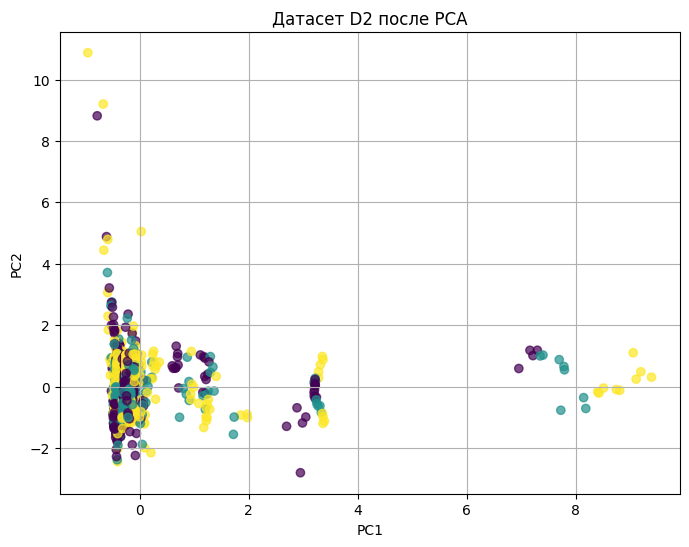

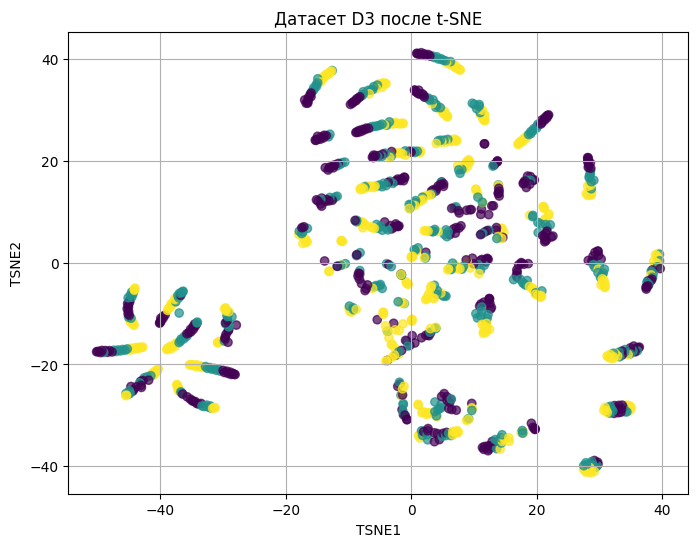

In [ ]:
category_map = {'низкий': 0, 'средний': 1, 'высокий': 2}
category_colors = df['Категория'].map(category_map)

plt.figure(figsize=(8, 6))
plt.scatter(D2_df['PC1'], D2_df['PC2'], c=category_colors, alpha=0.7)
plt.title('Датасет D2 после PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(D3_df['TSNE1'], D3_df['TSNE2'], c=category_colors, alpha=0.7)
plt.title('Датасет D3 после t-SNE')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.grid(True)
plt.show()

## 8. Функция оценки качества кластеризации

Для оценки качества используются три метрики:

- **Silhouette Score** — чем больше значение, тем лучше;
- **Calinski-Harabasz Index** — чем больше значение, тем лучше;
- **Davies-Bouldin Index** — чем меньше значение, тем лучше.

Для DBSCAN отдельно учитывается возможное появление шумовых объектов с меткой `-1`.

In [ ]:
def evaluate_clustering(data, labels, dataset_name, method_name):
    labels = np.array(labels)

    # Для DBSCAN шумовые точки имеют метку -1.
    # Для корректного расчёта метрик исключим шум, если он есть.
    mask = labels != -1
    labels_without_noise = labels[mask]
    data_without_noise = data[mask]

    unique_labels = np.unique(labels_without_noise)

    if len(unique_labels) < 2:
        return {
            'Датасет': dataset_name,
            'Метод': method_name,
            'Количество кластеров': len(unique_labels),
            'Silhouette': np.nan,
            'Calinski-Harabasz': np.nan,
            'Davies-Bouldin': np.nan
        }

    return {
        'Датасет': dataset_name,
        'Метод': method_name,
        'Количество кластеров': len(unique_labels),
        'Silhouette': silhouette_score(data_without_noise, labels_without_noise),
        'Calinski-Harabasz': calinski_harabasz_score(data_without_noise, labels_without_noise),
        'Davies-Bouldin': davies_bouldin_score(data_without_noise, labels_without_noise)
    }

## 9. Кластеризация датасетов D1, D2 и D3

Для каждого датасета применяется три метода кластеризации:

1. KMeans;
2. Agglomerative Clustering;
3. DBSCAN.

In [ ]:
datasets = {
    'D1': D1,
    'D2': D2,
    'D3': D3
}

all_results = []
cluster_labels = {}

for dataset_name, data in datasets.items():

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_kmeans, dataset_name, 'KMeans'))
    cluster_labels[(dataset_name, 'KMeans')] = labels_kmeans

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=3)
    labels_agglomerative = agglomerative.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_agglomerative, dataset_name, 'Agglomerative'))
    cluster_labels[(dataset_name, 'Agglomerative')] = labels_agglomerative

    # DBSCAN
    if dataset_name == 'D1':
        dbscan = DBSCAN(eps=1.5, min_samples=5)
    else:
        dbscan = DBSCAN(eps=3.0, min_samples=5)

    labels_dbscan = dbscan.fit_predict(data)
    all_results.append(evaluate_clustering(data, labels_dbscan, dataset_name, 'DBSCAN'))
    cluster_labels[(dataset_name, 'DBSCAN')] = labels_dbscan

results_df = pd.DataFrame(all_results)

print("Результаты кластеризации:")
print(results_df)

Результаты кластеризации:
  Датасет          Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
0      D1         KMeans                     3    0.212700         343.938142   
1      D1  Agglomerative                     3    0.173537         303.795471   
2      D1         DBSCAN                     7    0.216967         210.245332   
3      D2         KMeans                     3    0.491296        1093.086347   
4      D2  Agglomerative                     3    0.455962         985.237525   
5      D2         DBSCAN                     2    0.846692        1158.854394   
6      D3         KMeans                     3    0.487831        1343.688965   
7      D3  Agglomerative                     3    0.481362        1069.197998   
8      D3         DBSCAN                    45    0.571405        2729.501953   

   Davies-Bouldin  
0        1.344890  
1        1.546596  
2        1.348571  
3        0.666580  
4        0.685653  
5        0.213886  
6        0.770718  
7  

## 10. Визуализация кластеризации для D2

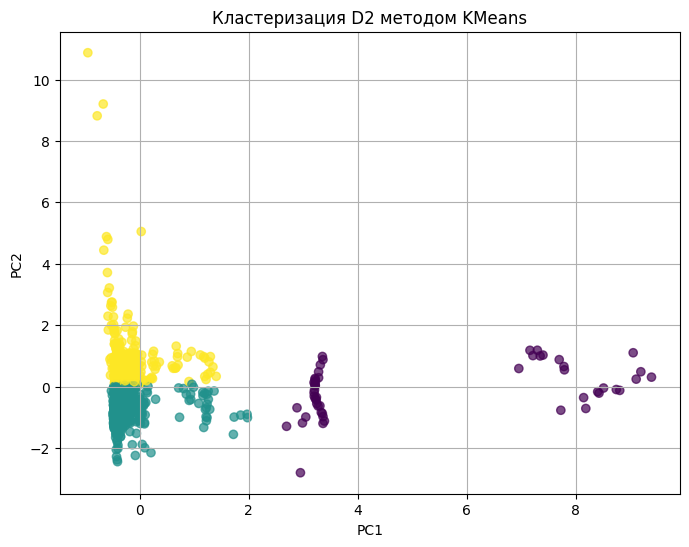

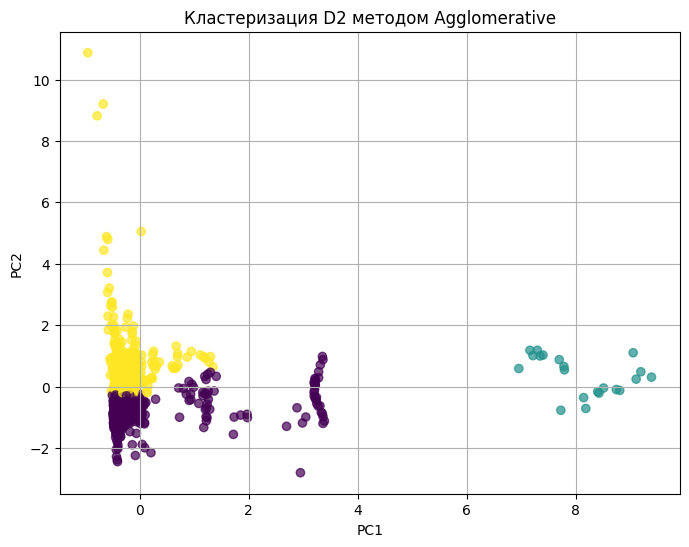

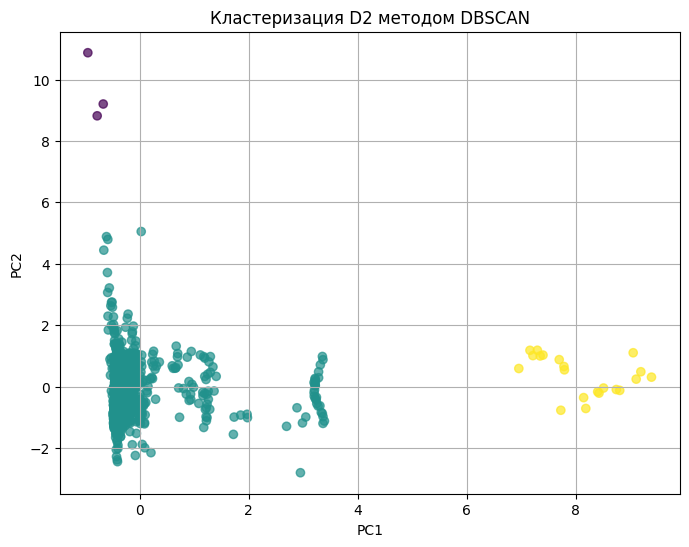

In [ ]:
for method in ['KMeans', 'Agglomerative', 'DBSCAN']:
    labels = cluster_labels[('D2', method)]

    plt.figure(figsize=(8, 6))
    plt.scatter(D2_df['PC1'], D2_df['PC2'], c=labels, alpha=0.7)
    plt.title(f'Кластеризация D2 методом {method}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True)
    plt.show()

## 11. Визуализация кластеризации для D3

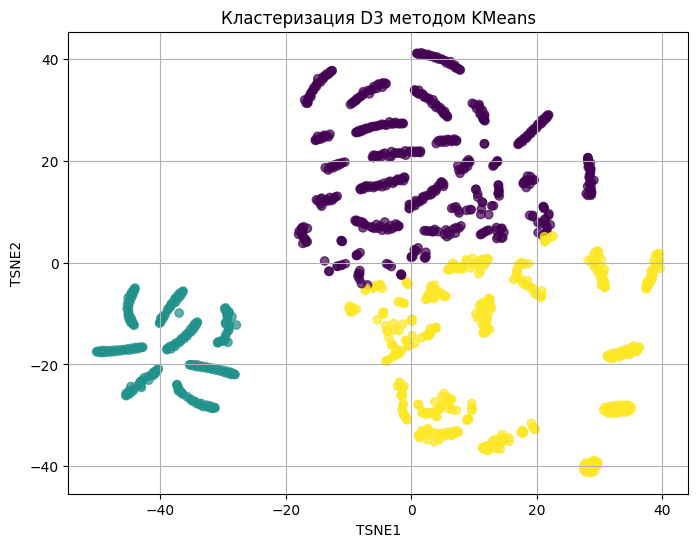

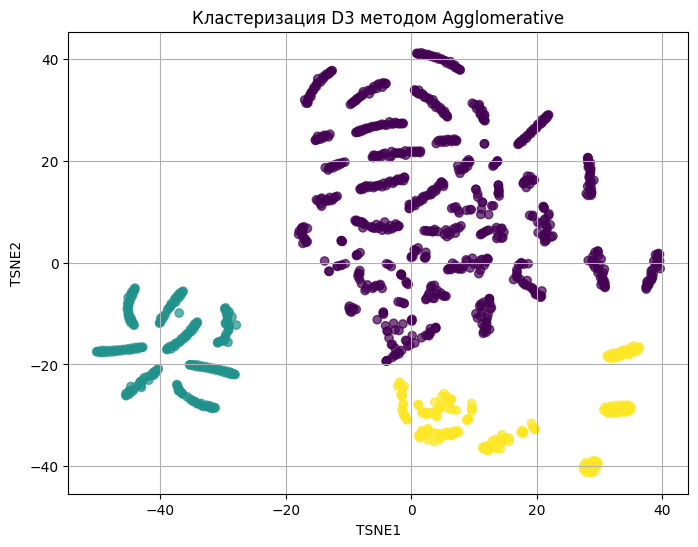

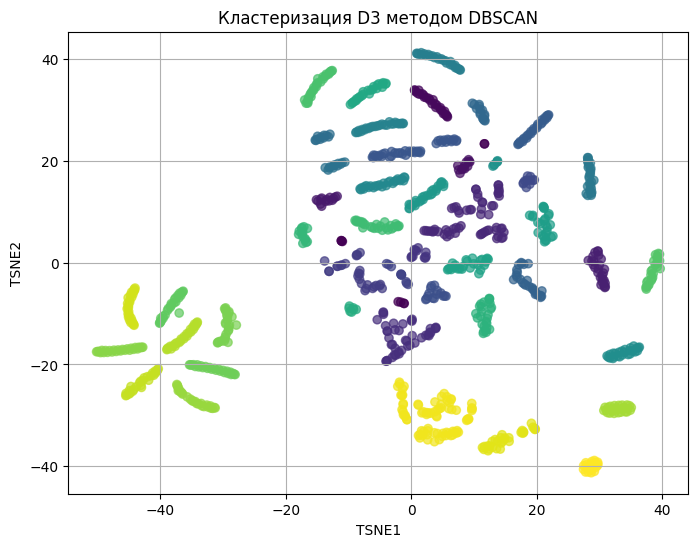

In [ ]:
for method in ['KMeans', 'Agglomerative', 'DBSCAN']:
    labels = cluster_labels[('D3', method)]

    plt.figure(figsize=(8, 6))
    plt.scatter(D3_df['TSNE1'], D3_df['TSNE2'], c=labels, alpha=0.7)
    plt.title(f'Кластеризация D3 методом {method}')
    plt.xlabel('TSNE1')
    plt.ylabel('TSNE2')
    plt.grid(True)
    plt.show()

## 12. Итоговое сравнение качества кластеризации

In [ ]:
results_df_sorted = results_df.sort_values(
    by=['Датасет', 'Silhouette'],
    ascending=[True, False]
)

print("Итоговое сравнение методов кластеризации:")
print(results_df_sorted)

Итоговое сравнение методов кластеризации:
  Датасет          Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
2      D1         DBSCAN                     7    0.216967         210.245332   
0      D1         KMeans                     3    0.212700         343.938142   
1      D1  Agglomerative                     3    0.173537         303.795471   
5      D2         DBSCAN                     2    0.846692        1158.854394   
3      D2         KMeans                     3    0.491296        1093.086347   
4      D2  Agglomerative                     3    0.455962         985.237525   
8      D3         DBSCAN                    45    0.571405        2729.501953   
6      D3         KMeans                     3    0.487831        1343.688965   
7      D3  Agglomerative                     3    0.481362        1069.197998   

   Davies-Bouldin  
2        1.348571  
0        1.344890  
1        1.546596  
5        0.213886  
3        0.666580  
4        0.685653  
8      

## 13. Лучший метод кластеризации для каждого датасета

In [ ]:
best_methods = (
    results_df
    .dropna()
    .sort_values(by='Silhouette', ascending=False)
    .groupby('Датасет')
    .head(1)
)

print("Лучший метод кластеризации для каждого датасета:")
print(best_methods)

Лучший метод кластеризации для каждого датасета:
  Датасет   Метод  Количество кластеров  Silhouette  Calinski-Harabasz  \
5      D2  DBSCAN                     2    0.846692        1158.854394   
8      D3  DBSCAN                    45    0.571405        2729.501953   
2      D1  DBSCAN                     7    0.216967         210.245332   

   Davies-Bouldin  
5        0.213886  
8        0.550376  
2        1.348571  


## 14. Вывод

В ходе лабораторной работы были изучены методы обучения без учителя на примере датасета `agriculture.csv`. Был сформирован датасет D1, включающий числовые и категориальные признаки без использования целевого признака. Для D1 было выполнено снижение размерности до двух признаков двумя способами: методом главных компонент PCA и методом t-SNE. Полученные датасеты D2 и D3 были визуализированы.

По визуальному анализу t-SNE обычно позволяет выделить группы объектов более явно, чем PCA, так как лучше сохраняет локальную структуру данных. Для датасетов D1, D2 и D3 была выполнена кластеризация с использованием трёх методов: KMeans, Agglomerative Clustering и DBSCAN. Качество кластеризации оценивалось с помощью метрик Silhouette Score, Calinski-Harabasz Index и Davies-Bouldin Index.

На основе сравнения метрик можно выбрать лучший метод кластеризации для каждого датасета. Наиболее качественным считается метод, у которого выше значения Silhouette и Calinski-Harabasz, а значение Davies-Bouldin ниже.